In [1]:
!pip -q install pandas numpy requests duckdb matplotlib seaborn plotly statsmodels

In [2]:
import requests

url = "https://scorecard.worldbank.org/en/api"

response = requests.get(url, timeout=30)

print("Status:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print(response.text[:1000])

Status: 200
Content type: text/html
<!doctype html>
<html lang="en" data-critters-container>
<head>
  <meta charset="utf-8">
  <title>Measuring Impact | World Bank Group Scorecard</title>
  <base href="/">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <link rel="icon" type="image/x-icon" href="favicon.ico">
  <link rel="canonical" href="https://scorecard.worldbank.org/">
  <link rel="preconnect" href="//assets.adobetm.com" crossorigin>
<link rel="dns-prefetch" href="//assets.adobetm.com">
<link rel="preconnect" href="//ext.api.worldbank.org" crossorigin>
<link rel="dns-prefetch" href="//ext.api.worldbank.org">
<link rel="preconnect" href="//scorecardcmsapi.worldbank.org" crossorigin>
<link rel="dns-prefetch" href="//scorecardcmsapi.worldbank.org">
<link rel="preconnect" href="//wwwstg.worldbank.org" crossorigin>
<link rel="dns-prefetch" href="//wwwstg.worldbank.org">
<link rel="preload" as="image" href="/assets/images/artboard-v1.png" type="image/svg+xml">
  

In [3]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(response.text, "html.parser")

for script in soup.find_all("script"):
    text = script.get_text()
    if "wbgData" in text or "api" in text.lower():
        print(text[:5000])


    var wbgData = {
      site: {
        pageLoad: 'N'
      }
    };
    window.addEventListener("load", (event) => {
      const script = document.createElement('script');
      script.setAttribute('src','//assets.adobedtm.com/223f6e2cf7c9/3eb6c9b72a93/launch-7bc0cdc67098.min.js');
      document.body.appendChild(script);
    });
  


In [4]:
import zipfile
from pathlib import Path

data_folder = Path("/content/scorecard_data")
data_folder.mkdir(exist_ok=True)

zip_files = list(Path("/content").glob("Scorecard_Summary_*.zip"))

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(data_folder)
    print("Extracted:", zip_path.name)

excel_files = list(data_folder.rglob("*.xlsx"))

print("\nZIP files found:", len(zip_files))
print("Excel files found:", len(excel_files))

for file in excel_files:
    print(file.relative_to(data_folder))

Extracted: Scorecard_Summary_WBGResults.zip
Extracted: Scorecard_Summary_ClientContext.zip
Extracted: Scorecard_Summary_Vision.zip

ZIP files found: 3
Excel files found: 51
ER_PTD_TOTL_ZS.xlsx
CSC_RES_DIG_ENA_SERV.xlsx
CSC_RES_GHG_EMS_YEAR.xlsx
EN_FSH_SUST_ZS.xlsx
CSC_RES_ELC_ACCS.xlsx
ER_NCA_RNEW.xlsx
CSC_RES_GEN_EQU_BENE.xlsx
CSC_RES_TER_AQU_HECT.xlsx
SI_POV_DDAY_TO.xlsx
EN_CLM_VULN.xlsx
SI_DST_INEQ.xlsx
EN_ATM_GHGT_GT_CE.xlsx
EN_ATM_HAZA.xlsx
CSC_RES_SOC_SAF_PROG.xlsx
CSC_RES_WAT_SAN_HYG_TOT.xlsx
CSC_RES_HEA_EMER_BENE.xlsx
SH_UHC_SRVS_CV_XD.xlsx
ER_LND_HEAL.xlsx
CSC_RES_EDU_SUPP.xlsx
SH_H2O_STA_HYGN_ZS_TO.xlsx
SN_ITK_MSFI_ZS.xlsx
SM_POP_FDIP.xlsx
CSC_RES_BRO_INTE.xlsx
SL_UEM_NEET_ME_TO.xlsx
CSC_RES_DEBT_SUST_RISK.xlsx
FI_DEB_RISK.xlsx
SL_EMP_WORK_TO.xlsx
CSC_RES_PRIV_CAP_ENAB.xlsx
CSC_RES_FIN_SERV_WOM.xlsx
CSC_RES_FOOD_NUTR_SECU.xlsx
IT_NET_USER_ZS.xlsx
CSC_RES_HEA_SERV.xlsx
CSC_RES_RESI_CLIM_RISK.xlsx
SH_STA_STNT_ME_ZS.xlsx
CSC_RES_ACCS_TRANS_INFRA_SERV.xlsx
SP_ROD_R2KM.xlsx
SI_POV

In [5]:
import pandas as pd

sample_file = data_folder / "CSC_RES_SOC_SAF_PROG.xlsx"

xls = pd.ExcelFile(sample_file)

print("SHEETS:", xls.sheet_names)

for sheet in xls.sheet_names:
    df = pd.read_excel(sample_file, sheet_name=sheet)

    print("\nSHEET:", sheet)
    print("SHAPE:", df.shape)
    print("COLUMNS:", df.columns.tolist())
    print("\nFIRST 5 ROWS:")
    display(df.head())


/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


SHEETS: ['Aggregates', 'WB Project Information', 'Dictionary']

SHEET: Aggregates
SHAPE: (1808, 15)
COLUMNS: ['Indicator_Code', 'Indicator_Name', 'Sub_Indicator_Code', 'Organization_Code', 'Indicator_Type', 'Geography_Type', 'Geography_Code', 'Geography_Name', 'Demographic_Disaggregation', 'Time_Period', 'Unit_Measure', 'Achieved_Results', 'Expected_Results', 'Disability_Inclusive_Flag', 'Observation_Note']

FIRST 5 ROWS:


,Indicator_Code,Indicator_Name,Sub_Indicator_Code,Organization_Code,Indicator_Type,Geography_Type,Geography_Code,Geography_Name,Demographic_Disaggregation,Time_Period,Unit_Measure,Achieved_Results,Expected_Results,Disability_Inclusive_Flag,Observation_Note
0,CSC_RES_SOC_SAF_PROG,Beneficiaries of social safety net programs,NaN,WBG,WBG Results,COUNTRY,GTM,Guatemala,Youth,2025-06-30,Beneficiaries,0.0,0.0,Total,NaN
1,CSC_RES_SOC_SAF_PROG,Beneficiaries of social safety net programs,NaN,WBG,WBG Results,COUNTRY,CPV,Cabo Verde,Youth,2025-06-30,Beneficiaries,0.0,0.0,Yes,NaN
2,CSC_RES_SOC_SAF_PROG,Beneficiaries of social safety net programs,NaN,WBG,WBG Results,COUNTRY,ECU,Ecuador,Youth,2025-06-30,Beneficiaries,0.0,0.0,Total,NaN
3,CSC_RES_SOC_SAF_PROG,Beneficiaries of social safety net programs,NaN,WB,WBG Results,COUNTRY,NGA,Nigeria,Female,2025-06-30,Beneficiaries,0.0,0.0,Yes,NaN
4,CSC_RES_SOC_SAF_PROG,Beneficiaries of social safety net programs,NaN,WBG,WBG Results,COUNTRY,ECU,Ecuador,Youth,2025-06-30,Beneficiaries,0.0,0.0,Yes,NaN


/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



SHEET: WB Project Information
SHAPE: (934, 56)
COLUMNS: ['Project_ID', 'Project_Name', 'Project_Development_Objective', 'Approval_Date', 'Closing_Date', 'WB_Region', 'CountryEconomy_Code', 'CountryEconomy_Name', 'Global_Department', 'Project_Status', 'Lending_Instrument', 'Project_Financier', 'Agreement_Type', 'Net_Commitment_Total', 'Net_Commitment_IBRD', 'Net_Commitment_IDA', 'Net_Commitment_Others', 'indicator_code', 'sub_indicator_code', 'Archive_Date_ISR_ICR_PAD', 'ISR_Sequence_Number_ICR_PAD', 'Reporting_FY', 'Project_Indicator_ID', 'Project_Indicator', 'Project_Indicator_Description', 'Unit_of_Measure', 'Baseline_Date', 'Baseline_Value', 'Baseline_Conversion_Factor', 'Baseline_Disaggregation_Factor', 'Calculated_Baseline_Value', 'Progress_Date', 'Progress_Value', 'Progress_Conversion_Factor', 'Progress_Disaggregation_Factor', 'Calculated_Progress_Value', 'Target_Date', 'Target_Value', 'Target_Conversion_Factor', 'Target_Disaggregation_Factor', 'Calculated_Target_Value', 'Achiev

,Project_ID,Project_Name,Project_Development_Objective,Approval_Date,Closing_Date,WB_Region,CountryEconomy_Code,CountryEconomy_Name,Global_Department,Project_Status,...,Expected_Results_IBRD,Demographic_Disaggregation,Disability_Inclusive_Flag,Double_Counting_Flag,FCV_Flag,Small_State_Flag,SIDS_Flag,LDC_Flag,Income_Group,Additional_Comments
0,P178988,DJI - Emergency Food Crisis Response,The project development objective is to contri...,2022-10-26,2025-12-31,MENAAP,DJI,Djibouti,AGR,A,...,0.0,Total,Yes,Y,N,Y,N,Y,LMC,NaN
1,P181475,MCLAP,To increase access of target beneficiaries to ...,2025-03-31,2027-01-15,EAP,MMR,Myanmar,AGR,A,...,0.0,Female,Yes,Y,Y,N,N,Y,LMC,NaN
2,P179512,Angola First Green Growth DPF,The development objective is to support the Go...,2023-06-30,2024-06-30,AFE,AGO,Angola,MTI,C,...,0.0,Total,Total,Y,N,N,N,Y,LMC,NaN
3,P132634,Safety Net Systems for the Poorest,The Project Development Objective is to improv...,2013-06-26,2024-12-31,SAR,BGD,Bangladesh,SPL,C,...,0.0,Total,Total,Y,N,N,N,Y,LMC,NaN
4,P168551,Rwanda Quality Basic Education,The PDO is to improve teacher competency and s...,2019-07-30,2027-10-31,AFE,RWA,Rwanda,EDU,A,...,0.0,Female,Yes,N,N,N,N,Y,LIC,NaN



SHEET: Dictionary
SHAPE: (70, 4)
COLUMNS: ['schema', 'seq_nbr', 'column_name', 'comment']

FIRST 5 ROWS:


/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,schema,seq_nbr,column_name,comment
0,Aggregates,1,Indicator_Code,Scorecard indicator code
1,Aggregates,2,Indicator_Name,Natural language indicator name
2,Aggregates,3,Sub_Indicator_Code,"Scorecard subindicator code (optional, where r..."
3,Aggregates,4,Organization_Code,WBG organization represented by aggregate value
4,Aggregates,5,Indicator_Type,Type of indicator


In [6]:
all_aggregates = []
all_projects = []
all_dictionaries = []

for file in excel_files:
    xls = pd.ExcelFile(file)

    if "Aggregates" in xls.sheet_names:
        df = pd.read_excel(file, sheet_name="Aggregates")
        df["Source_File"] = file.name
        all_aggregates.append(df)

    if "WB Project Information" in xls.sheet_names:
        df = pd.read_excel(file, sheet_name="WB Project Information")
        df["Source_File"] = file.name
        all_projects.append(df)

    if "Dictionary" in xls.sheet_names:
        df = pd.read_excel(file, sheet_name="Dictionary")
        df["Source_File"] = file.name
        all_dictionaries.append(df)

aggregates = pd.concat(all_aggregates, ignore_index=True)
projects = pd.concat(all_projects, ignore_index=True)
dictionary = pd.concat(all_dictionaries, ignore_index=True)

print("Indicators loaded:", len(excel_files))
print("Aggregate observations:", len(aggregates))
print("Project-level observations:", len(projects))
print("Dictionary entries:", len(dictionary))

print("\nFiscal periods:")
print(aggregates["Time_Period"].value_counts().head(10))

print("\nIndicator types:")
print(aggregates["Indicator_Type"].value_counts())

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default sty

Indicators loaded: 51
Aggregate observations: 132638
Project-level observations: 19814
Dictionary entries: 1750

Fiscal periods:
Time_Period
2025-06-30    34800
2021           4956
2017           4631
2020           4568
2023           4481
2014           4451
2022           4426
2019           4417
2018           4414
2015           4370
Name: count, dtype: int64

Indicator types:
Indicator_Type
Client Context    64928
WBG Results       34800
Vision            32910
Name: count, dtype: int64


/tmp/ipykernel_1753/1687797230.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  projects = pd.concat(all_projects, ignore_index=True)
/tmp/ipykernel_1753/1687797230.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  projects = pd.concat(all_projects, ignore_index=True)


In [7]:
# Identify available indicators and time periods
coverage = (
    aggregates.groupby(["Indicator_Type", "Indicator_Code"])
    .agg(
        indicator_name=("Indicator_Name", "first"),
        observations=("Indicator_Code", "size"),
        periods=("Time_Period", "nunique"),
        countries=("Geography_Code", "nunique")
    )
    .reset_index()
)

print("INDICATOR COVERAGE")
display(coverage)

print("\nWBG RESULTS: GEOGRAPHY TYPES")
print(
    aggregates.loc[
        aggregates["Indicator_Type"] == "WBG Results",
        "Geography_Type"
    ].value_counts(dropna=False)
)

print("\nWBG RESULTS: TIME PERIODS")
print(
    aggregates.loc[
        aggregates["Indicator_Type"] == "WBG Results",
        "Time_Period"
    ].value_counts(dropna=False)
)

print("\nPROJECT DATA: UNIQUE PROJECTS")
print(projects["Project_ID"].nunique())

print("\nPROJECT DATA: EXACT DUPLICATE ROWS")
print(projects.duplicated().sum())

INDICATOR COVERAGE


,Indicator_Type,Indicator_Code,indicator_name,observations,periods,countries
0,Client Context,CSC_CLI_EXT_POOR_FCS,Percentage of population in FCS countries/econ...,380,25,45
1,Client Context,EG_ELC_ACCS_ZS,Percentage of population with access to electr...,4136,24,173
2,Client Context,EN_ATM_HAZA,Percentage of people exposed to hazardous air ...,4439,23,193
3,Client Context,EN_FSH_SUST_ZS,Proportion of fish stocks within biologically ...,111,3,60
4,Client Context,ER_NCA_RNEW,Number of countries/economies with increasing ...,24,1,24
5,Client Context,ER_PTD_TOTL_ZS,Percentage of terrestrial and aquatic areas th...,2481,13,192
6,Client Context,FI_DEB_RISK,Number of countries/economies at high risk of ...,585,5,117
7,Client Context,FI_TAX_GD_ZS,Number of countries/economies with tax revenue...,1274,26,49
8,Client Context,FX_OWN_TOTL_FE_ZS,"Population that own a financial account, femal...",739,5,164
9,Client Context,FX_OWN_TOTL_ZS,"Population that own a financial account, total...",739,5,164



WBG RESULTS: GEOGRAPHY TYPES
Geography_Type
COUNTRY       27307
REGION         3734
INCOME         2000
FCS             467
LDC             453
SIDS            424
SMALLSTATE      415
Name: count, dtype: int64

WBG RESULTS: TIME PERIODS
Time_Period
2025-06-30    34800
Name: count, dtype: int64

PROJECT DATA: UNIQUE PROJECTS
2073

PROJECT DATA: EXACT DUPLICATE ROWS
0


In [8]:
wbg = aggregates[
    aggregates["Indicator_Type"] == "WBG Results"
].copy()

print("ORGANIZATIONS")
print(wbg["Organization_Code"].value_counts(dropna=False))

print("\nDEMOGRAPHIC DISAGGREGATIONS")
print(wbg["Demographic_Disaggregation"].value_counts(dropna=False))

print("\nGEOGRAPHIC LEVELS")
print(wbg["Geography_Type"].value_counts(dropna=False))

print("\nSUB-INDICATORS")
print(wbg["Sub_Indicator_Code"].value_counts(dropna=False).head(20))

print("\nRESULTS DATA AVAILABILITY")
print(wbg[["Achieved_Results", "Expected_Results"]].notna().sum())

print("\nSAMPLE RECORDS")
display(
    wbg[
        [
            "Indicator_Name",
            "Organization_Code",
            "Geography_Type",
            "Geography_Name",
            "Demographic_Disaggregation",
            "Achieved_Results",
            "Expected_Results"
        ]
    ].head(10)
)

ORGANIZATIONS
Organization_Code
WBG     10759
WB       9705
IDA      6610
IFC      3933
IBRD     3514
MIGA      279
Name: count, dtype: int64

DEMOGRAPHIC DISAGGREGATIONS
Demographic_Disaggregation
Total     15193
Female    10266
Youth      9341
Name: count, dtype: int64

GEOGRAPHIC LEVELS
Geography_Type
COUNTRY       27307
REGION         3734
INCOME         2000
FCS             467
LDC             453
SIDS            424
SMALLSTATE      415
Name: count, dtype: int64

SUB-INDICATORS
Sub_Indicator_Code
NaN                              22372
CSC_RES_GEN_EQU                   3147
CSC_RES_BENE_ENAB_ECO_OPP         3005
CSC_RES_WAT_SAN_HYG               1777
CSC_RES_FIN_SERV_WOM_CUS          1118
CSC_RES_FIN_SERV                   982
CSC_RES_WAT_SAN_SAFE               824
CSC_RES_ELC_ACCS_EXIS_CONN         822
CSC_RES_ELC_INF_ACCS_NEW_CONN      753
Name: count, dtype: int64

RESULTS DATA AVAILABILITY
Achieved_Results    33150
Expected_Results    34784
dtype: int64

SAMPLE RECORDS


,Indicator_Name,Organization_Code,Geography_Type,Geography_Name,Demographic_Disaggregation,Achieved_Results,Expected_Results
2481,Number of people using digitally enabled services,IFC,COUNTRY,China,Female,147610.0,661298.0
2482,Number of people using digitally enabled services,IDA,COUNTRY,Niger,Total,148307.0,93000.0
2483,Number of people using digitally enabled services,WBG,COUNTRY,Eswatini,Total,1500.0,21000.0
2484,Number of people using digitally enabled services,WB,COUNTRY,Madagascar,Youth,71592.0,47285.0
2485,Number of people using digitally enabled services,WBG,COUNTRY,Tunisia,Youth,87073.0,128000.0
2486,Number of people using digitally enabled services,IBRD,REGION,"Middle East, North Africa, Afghanistan, and Pa...",Youth,99574.0,667070.0
2487,Number of people using digitally enabled services,WBG,COUNTRY,Kosovo,Total,0.0,363540.0
2488,Number of people using digitally enabled services,IDA,COUNTRY,"Gambia, The",Female,0.0,153000.0
2489,Number of people using digitally enabled services,WB,COUNTRY,Serbia,Youth,0.0,3900.0
2490,Number of people using digitally enabled services,WBG,COUNTRY,Guinea-Bissau,Youth,0.0,56027.0


In [9]:
analysis = wbg[
    (wbg["Organization_Code"] == "WBG") &
    (wbg["Geography_Type"] == "COUNTRY") &
    (wbg["Demographic_Disaggregation"] == "Total") &
    (wbg["Sub_Indicator_Code"].isna())
].copy()

print("Observations:", len(analysis))
print("Indicators:", analysis["Indicator_Code"].nunique())
print("Countries:", analysis["Geography_Code"].nunique())

print("\nINDICATORS INCLUDED")
display(
    analysis[
        ["Indicator_Code", "Indicator_Name", "Unit_Measure"]
    ].drop_duplicates().sort_values("Indicator_Code")
)

print("\nDUPLICATE INDICATOR-COUNTRY RECORDS")
print(
    analysis.duplicated(
        ["Indicator_Code", "Geography_Code", "Time_Period"]
    ).sum()
)

print("\nMISSING RESULTS")
print(
    analysis[["Achieved_Results", "Expected_Results"]]
    .isna().sum()
)

Observations: 2541
Indicators: 18
Countries: 146

INDICATORS INCLUDED


,Indicator_Code,Indicator_Name,Unit_Measure
96014,CSC_RES_ACCS_TRANS_INFRA_SERV,Number of people that benefit from improved ac...,Beneficiaries
59325,CSC_RES_BRO_INTE,Number of people using broadband internet,Beneficiaries
68230,CSC_RES_DEBT_SUST_RISK,Percentage of economies in or at high risk of ...,Percentage
2483,CSC_RES_DIG_ENA_SERV,Number of people using digitally enabled services,Beneficiaries
101615,CSC_RES_DISP_COMM_SERVICES,Number of displaced people and people in host ...,Beneficiaries
41288,CSC_RES_EDU_SUPP,Students supported with better education,Beneficiaries
5374,CSC_RES_ELC_ACCS,Number of people provided with access to elect...,Beneficiaries
80918,CSC_RES_FOOD_NUTR_SECU,Number of people with strengthened food and nu...,Beneficiaries
4576,CSC_RES_GHG_EMS_YEAR,Net GHG Emissions,MtCO2eq/year
36167,CSC_RES_HEA_EMER_BENE,Number of economies benefitting from strengthe...,Countries/Economies



DUPLICATE INDICATOR-COUNTRY RECORDS
878

MISSING RESULTS
Achieved_Results    417
Expected_Results      0
dtype: int64


In [10]:
keys = ["Indicator_Code", "Geography_Code", "Time_Period"]

duplicates = analysis[
    analysis.duplicated(keys, keep=False)
].copy()

print("Rows involved in duplicate groups:", len(duplicates))

print("\nDISABILITY FLAGS")
print(
    duplicates["Disability_Inclusive_Flag"]
    .value_counts(dropna=False)
)

print("\nEXAMPLE DUPLICATE GROUPS")
display(
    duplicates.sort_values(keys)[
        keys + [
            "Disability_Inclusive_Flag",
            "Achieved_Results",
            "Expected_Results",
            "Observation_Note"
        ]
    ].head(20)
)

Rows involved in duplicate groups: 1700

DISABILITY FLAGS
Disability_Inclusive_Flag
Total    869
Yes      831
Name: count, dtype: int64

EXAMPLE DUPLICATE GROUPS


,Indicator_Code,Geography_Code,Time_Period,Disability_Inclusive_Flag,Achieved_Results,Expected_Results,Observation_Note
96727,CSC_RES_ACCS_TRANS_INFRA_SERV,ALB,2025-06-30,Yes,0.0,350000.0,NaN
97452,CSC_RES_ACCS_TRANS_INFRA_SERV,ALB,2025-06-30,Total,0.0,350000.0,NaN
96286,CSC_RES_ACCS_TRANS_INFRA_SERV,ARG,2025-06-30,Total,2915627.0,1.3786642E7,NaN
96377,CSC_RES_ACCS_TRANS_INFRA_SERV,ARG,2025-06-30,Yes,0.0,1.0807469E7,NaN
97040,CSC_RES_ACCS_TRANS_INFRA_SERV,AZE,2025-06-30,Total,103300.0,103300.0,NaN
97808,CSC_RES_ACCS_TRANS_INFRA_SERV,AZE,2025-06-30,Yes,103300.0,103300.0,NaN
96586,CSC_RES_ACCS_TRANS_INFRA_SERV,BDI,2025-06-30,Total,0.0,3067543.0,NaN
96710,CSC_RES_ACCS_TRANS_INFRA_SERV,BDI,2025-06-30,Yes,0.0,3067543.0,NaN
96220,CSC_RES_ACCS_TRANS_INFRA_SERV,BEN,2025-06-30,Yes,0.0,2220000.0,NaN
97481,CSC_RES_ACCS_TRANS_INFRA_SERV,BEN,2025-06-30,Total,0.0,2967869.0,NaN


In [11]:
 clean = analysis[
    analysis["Disability_Inclusive_Flag"] == "Total"
].copy()

keys = ["Indicator_Code", "Geography_Code", "Time_Period"]

print("Clean observations:", len(clean))
print("Indicators:", clean["Indicator_Code"].nunique())
print("Countries:", clean["Geography_Code"].nunique())

print("\nRemaining duplicate indicator-country-period records:")
print(clean.duplicated(keys).sum())

print("\nMissing achieved results:")
print(clean["Achieved_Results"].isna().sum())

print("\nMissing expected results:")
print(clean["Expected_Results"].isna().sum())

Clean observations: 1710
Indicators: 18
Countries: 146

Remaining duplicate indicator-country-period records:
47

Missing achieved results:
417

Missing expected results:
0


In [12]:
keys = ["Indicator_Code", "Geography_Code", "Time_Period"]

remaining = clean[
    clean.duplicated(keys, keep=False)
].copy()

print("Rows involved:", len(remaining))

print("\nIndicators affected:")
print(remaining["Indicator_Code"].value_counts())

print("\nOrganizations:")
print(remaining["Organization_Code"].value_counts(dropna=False))

print("\nSub-indicators:")
print(remaining["Sub_Indicator_Code"].value_counts(dropna=False))

print("\nExample records:")
display(
    remaining.sort_values(keys)[
        keys + [
            "Organization_Code",
            "Disability_Inclusive_Flag",
            "Achieved_Results",
            "Expected_Results",
            "Observation_Note",
            "Source_File"
        ]
    ].head(20)
)

Rows involved: 55

Indicators affected:
Indicator_Code
CSC_RES_GHG_EMS_YEAR      17
CSC_RES_PRIV_CAP_MOBL     16
CSC_RES_DIG_ENA_SERV       9
CSC_RES_RESI_CLIM_RISK     4
CSC_RES_EDU_SUPP           3
CSC_RES_ELC_ACCS           2
CSC_RES_TER_AQU_HECT       2
CSC_RES_REN_ENER_ENAB      2
Name: count, dtype: int64

Organizations:
Organization_Code
WBG    55
Name: count, dtype: int64

Sub-indicators:
Sub_Indicator_Code
NaN    55
Name: count, dtype: int64

Example records:


,Indicator_Code,Geography_Code,Time_Period,Organization_Code,Disability_Inclusive_Flag,Achieved_Results,Expected_Results,Observation_Note,Source_File
2561,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
2576,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
2783,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
2954,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
3095,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
3125,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
3128,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
3178,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,1802103.0,1.1645735E7,NaN,CSC_RES_DIG_ENA_SERV.xlsx
3356,CSC_RES_DIG_ENA_SERV,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_DIG_ENA_SERV.xlsx
42026,CSC_RES_EDU_SUPP,NaN,2025-06-30,WBG,Total,ND,ND,NaN,CSC_RES_EDU_SUPP.xlsx


In [13]:
country_data = clean[
    clean["Geography_Code"].notna()
].copy()

keys = ["Indicator_Code", "Geography_Code", "Time_Period"]

print("Country-level observations:", len(country_data))
print("Indicators:", country_data["Indicator_Code"].nunique())
print("Countries:", country_data["Geography_Code"].nunique())

print("\nRemaining duplicate records:")
print(country_data.duplicated(keys).sum())

print("\nMissing achieved results:")
print(country_data["Achieved_Results"].isna().sum())

print("\nMissing expected results:")
print(country_data["Expected_Results"].isna().sum())

Country-level observations: 1653
Indicators: 18
Countries: 146

Remaining duplicate records:
0

Missing achieved results:
406

Missing expected results:
0


/tmp/ipykernel_1753/1534717722.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


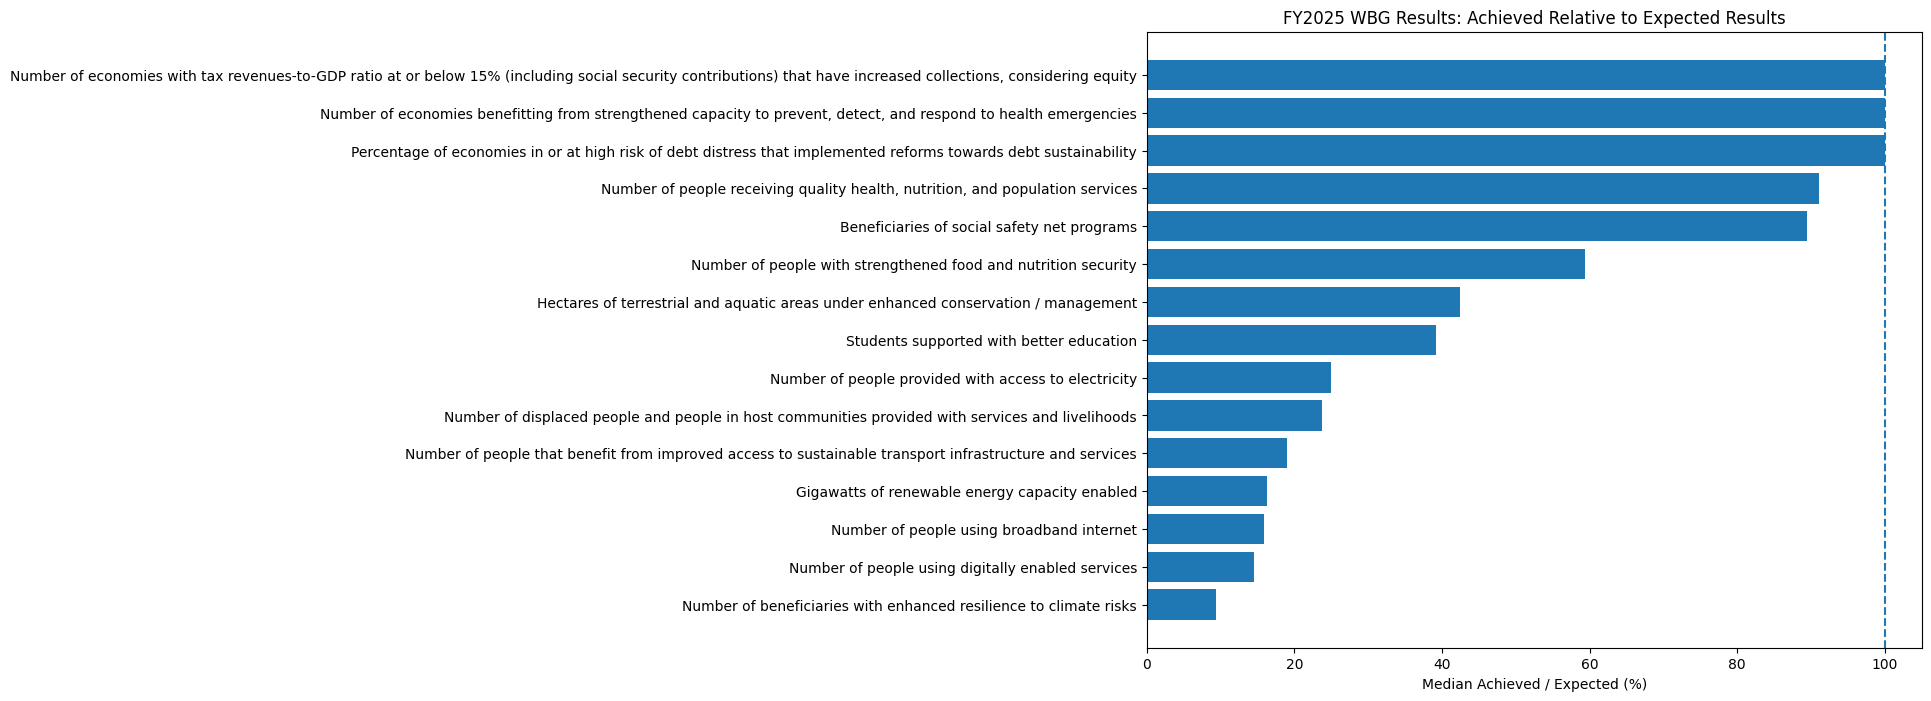

,Indicator_Name,Achieved_vs_Expected_Pct
0,Number of beneficiaries with enhanced resilien...,9.4
1,Number of people using digitally enabled services,14.6
2,Number of people using broadband internet,15.9
3,Gigawatts of renewable energy capacity enabled,16.2
4,Number of people that benefit from improved ac...,19.0
5,Number of displaced people and people in host ...,23.7
6,Number of people provided with access to elect...,24.9
7,Students supported with better education,39.2
8,Hectares of terrestrial and aquatic areas unde...,42.4
9,Number of people with strengthened food and nu...,59.4


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Keep observations where both values are numeric
performance = country_data.copy()

performance["Achieved_Results"] = pd.to_numeric(
    performance["Achieved_Results"], errors="coerce"
)

performance["Expected_Results"] = pd.to_numeric(
    performance["Expected_Results"], errors="coerce"
)

# Ratio only where expected results are positive
performance["Achieved_vs_Expected_Pct"] = np.where(
    performance["Expected_Results"] > 0,
    (performance["Achieved_Results"] / performance["Expected_Results"]) * 100,
    np.nan
)

# Indicator-level median ratio
indicator_performance = (
    performance.groupby(["Indicator_Code", "Indicator_Name"])
    ["Achieved_vs_Expected_Pct"]
    .median()
    .dropna()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10, 8))

plt.barh(
    indicator_performance["Indicator_Name"],
    indicator_performance["Achieved_vs_Expected_Pct"]
)

plt.axvline(100, linestyle="--")

plt.xlabel("Median Achieved / Expected (%)")
plt.ylabel("")
plt.title("FY2025 WBG Results: Achieved Relative to Expected Results")

plt.tight_layout()
plt.show()

display(
    indicator_performance[
        ["Indicator_Name", "Achieved_vs_Expected_Pct"]
    ].round(1)
)

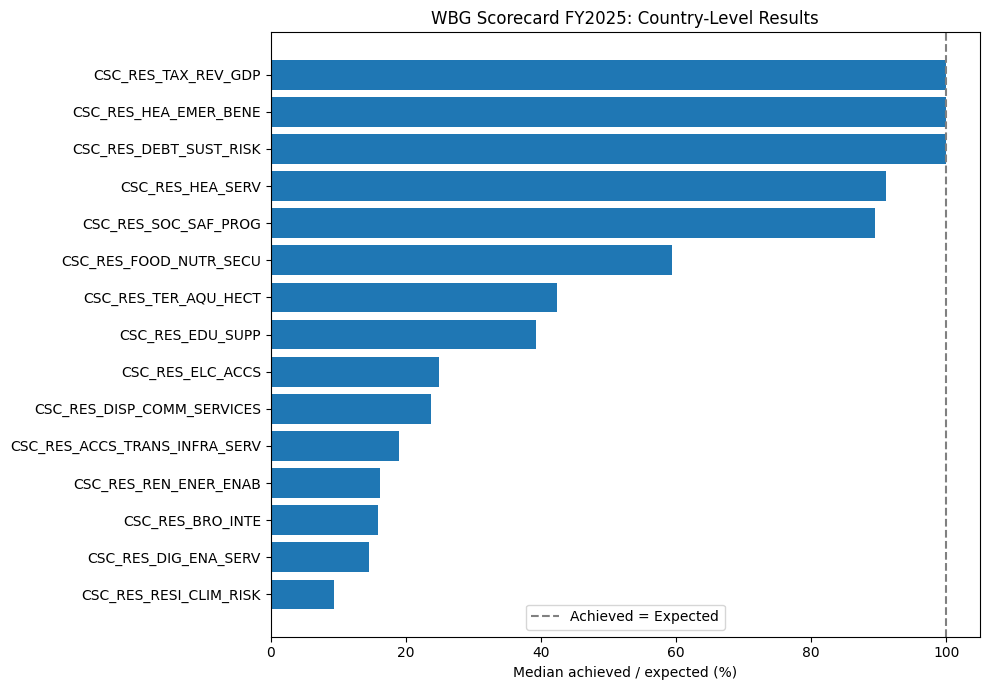

In [15]:
# Use short indicator codes instead of long names
chart_data = indicator_performance.sort_values(
    "Achieved_vs_Expected_Pct"
)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    chart_data["Indicator_Code"],
    chart_data["Achieved_vs_Expected_Pct"]
)

ax.axvline(100, color="gray", linestyle="--", label="Achieved = Expected")

ax.set_xlabel("Median achieved / expected (%)")
ax.set_title("WBG Scorecard FY2025: Country-Level Results")
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
coverage_check = (
    performance.groupby(["Indicator_Code", "Indicator_Name"])
    .agg(
        countries=("Geography_Code", "nunique"),
        valid_ratios=("Achieved_vs_Expected_Pct", "count"),
        median_ratio=("Achieved_vs_Expected_Pct", "median"),
        missing_achieved=("Achieved_Results", lambda x: x.isna().sum()),
        zero_expected=("Expected_Results", lambda x: (x == 0).sum())
    )
    .reset_index()
)

display(
    coverage_check[
        [
            "Indicator_Code",
            "countries",
            "valid_ratios",
            "median_ratio",
            "missing_achieved",
            "zero_expected"
        ]
    ].round(1)
)

,Indicator_Code,countries,valid_ratios,median_ratio,missing_achieved,zero_expected
0,CSC_RES_ACCS_TRANS_INFRA_SERV,91,91,19.0,0,0
1,CSC_RES_BRO_INTE,72,51,15.9,21,0
2,CSC_RES_DEBT_SUST_RISK,58,38,100.0,0,20
3,CSC_RES_DIG_ENA_SERV,102,84,14.6,17,1
4,CSC_RES_DISP_COMM_SERVICES,45,40,23.7,2,3
5,CSC_RES_EDU_SUPP,109,105,39.2,4,0
6,CSC_RES_ELC_ACCS,105,82,24.9,1,22
7,CSC_RES_FOOD_NUTR_SECU,108,105,59.4,2,1
8,CSC_RES_GHG_EMS_YEAR,134,0,NaN,134,1
9,CSC_RES_HEA_EMER_BENE,66,21,100.0,45,0


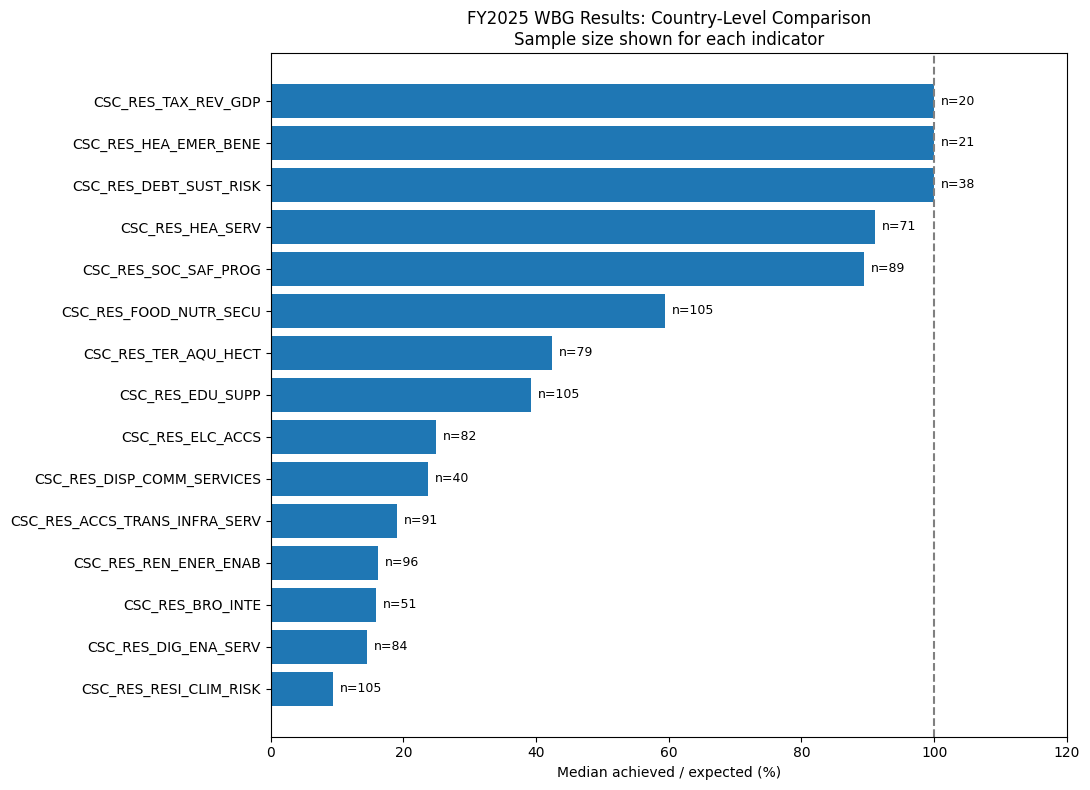

In [17]:
chart = coverage_check[
    coverage_check["valid_ratios"] > 0
].sort_values("median_ratio").copy()

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    chart["Indicator_Code"],
    chart["median_ratio"]
)

ax.axvline(100, color="gray", linestyle="--")

for bar, n in zip(bars, chart["valid_ratios"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"n={n}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 120)
ax.set_xlabel("Median achieved / expected (%)")
ax.set_title("FY2025 WBG Results: Country-Level Comparison\nSample size shown for each indicator")

plt.tight_layout()
plt.show()

In [18]:
print("PROJECT STATUS")
print(projects["Project_Status"].value_counts(dropna=False))

print("\nREPORTING FISCAL YEARS")
print(projects["Reporting_FY"].value_counts(dropna=False).head(15))

print("\nDATE AVAILABILITY")
print(
    projects[
        ["Baseline_Date", "Progress_Date", "Target_Date", "Closing_Date"]
    ].notna().sum()
)

print("\nVALUE AVAILABILITY")
print(
    projects[
        [
            "Calculated_Baseline_Value",
            "Calculated_Progress_Value",
            "Calculated_Target_Value"
        ]
    ].notna().sum()
)

print("\nSAMPLE PROJECT INDICATORS")
display(
    projects[
        [
            "Project_ID",
            "Project_Indicator",
            "Calculated_Baseline_Value",
            "Calculated_Progress_Value",
            "Calculated_Target_Value",
            "Progress_Date",
            "Target_Date"
        ]
    ].head(10)
)

PROJECT STATUS
Project_Status
A      15739
C       3943
NaN      132
Name: count, dtype: int64

REPORTING FISCAL YEARS
Reporting_FY
2025.0    18102
NaN        1382
2024.0      272
2023.0       41
2026.0       13
2022.0        4
Name: count, dtype: int64

DATE AVAILABILITY
Baseline_Date    16329
Progress_Date    15356
Target_Date      16525
Closing_Date     19648
dtype: int64

VALUE AVAILABILITY
Calculated_Baseline_Value    18397
Calculated_Progress_Value    18382
Calculated_Target_Value      18396
dtype: int64

SAMPLE PROJECT INDICATORS


,Project_ID,Project_Indicator,Calculated_Baseline_Value,Calculated_Progress_Value,Calculated_Target_Value,Progress_Date,Target_Date
0,P504693,IN00030131-Y: People reached with digitally en...,0.00,0.00,1700000.0,2024-12-13,2028-12-14
1,P176108,IN00042583: People using digitally enabled ser...,0.00,0.00,1500.0,2025-02-07,2027-03-15
2,P168551,IN01387814-Y: 4. Number of TTC final year stud...,0.00,0.00,7500.0,2025-04-08,2027-10-31
3,P174402,IN01136567: Female users of digitally enabled ...,0.00,0.00,0.0,NaT,NaT
4,P176544,IN00027200: People using digitally enabled ser...,0.00,0.00,0.0,2025-03-12,2027-05-15
5,P505095,IN00020788: People using digitally enabled ser...,0.00,0.00,2000000.0,2025-03-21,2030-10-14
6,P170718,IN00042549: People using digitally enabled ser...,0.00,0.00,2500.0,2025-06-01,2027-03-10
7,P179138,IN00031054: People using digitally enabled ser...,0.00,0.00,700000.0,2025-03-14,2029-12-12
8,P177947,IN01333632: Adults that made or received a dig...,1370602.89,1370602.89,2030522.8,2025-03-31,2028-05-31
9,P500570,IN00020803: People using digitally enabled ser...,0.00,0.00,630000.0,2025-05-20,2030-06-12


In [19]:
project_analysis = projects.copy()

columns = [
    "Calculated_Baseline_Value",
    "Calculated_Progress_Value",
    "Calculated_Target_Value"
]

for col in columns:
    project_analysis[col] = pd.to_numeric(
        project_analysis[col], errors="coerce"
    )

b = project_analysis["Calculated_Baseline_Value"]
p = project_analysis["Calculated_Progress_Value"]
t = project_analysis["Calculated_Target_Value"]

# Initial analysis: increasing targets only
project_analysis["Progress_Pct"] = np.where(
    (t > b) & b.notna() & p.notna() & t.notna(),
    ((p - b) / (t - b)) * 100,
    np.nan
)

print("Total indicator records:", len(project_analysis))
print("Records with increasing targets:", (t > b).sum())
print("Valid progress calculations:", project_analysis["Progress_Pct"].notna().sum())
print("Decreasing targets:", (t < b).sum())
print("Unchanged targets:", (t == b).sum())

print("\nPROGRESS DISTRIBUTION")
print(
    project_analysis["Progress_Pct"]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .round(1)
)


Total indicator records: 19814
Records with increasing targets: 11224
Valid progress calculations: 11212
Decreasing targets: 9
Unchanged targets: 7147

PROGRESS DISTRIBUTION
count    11212.0
mean        86.8
std        889.5
min       -400.0
25%          0.0
50%          3.3
75%         91.2
max      58675.4
Name: Progress_Pct, dtype: float64


In [20]:
print("PROGRESS CATEGORIES")

progress = project_analysis["Progress_Pct"]

print("Below 0%:", (progress < 0).sum())
print("0% to 100%:", progress.between(0, 100).sum())
print("Above 100%:", (progress > 100).sum())
print("Above 500%:", (progress > 500).sum())

print("\nTOP 10 EXTREME VALUES")

display(
    project_analysis.nlargest(10, "Progress_Pct")[
        [
            "Project_ID",
            "Project_Indicator",
            "Calculated_Baseline_Value",
            "Calculated_Progress_Value",
            "Calculated_Target_Value",
            "Progress_Pct"
        ]
    ].round(2)
)

PROGRESS CATEGORIES
Below 0%: 11
0% to 100%: 9037
Above 100%: 2164
Above 500%: 237

TOP 10 EXTREME VALUES


,Project_ID,Project_Indicator,Calculated_Baseline_Value,Calculated_Progress_Value,Calculated_Target_Value,Progress_Pct
18298,P164498,IN01345712: Roads rehablitated,0.00,261874.00,446.31,58675.36
18311,P164498,IN01345712: Roads rehablitated,0.00,261874.00,446.31,58675.36
276,P164032,IN01380614: Of which female,0.00,11700.00,40.00,29250.00
9431,P158215,IN01366894: 2.5 Area of green space constructe...,0.00,12.79,0.05,23938.20
11396,P160250,"IN00025532-F: People provided with water, sani...",50217.62,434947.34,57317.89,5418.52
11381,P160250,"IN00025532-Y: People provided with water, sani...",17039.59,147584.17,19448.82,5418.52
11413,P160250,"IN00025532: People provided with water, sanita...",100000.00,866125.00,114139.00,5418.52
11243,P156739,IN01409088-Y: Number of female students who ga...,0.00,426320.00,9000.00,4736.89
11262,P156739,IN01409088-F: Number of female students who ga...,0.00,426320.00,9000.00,4736.89
11304,P156739,IN01409088: Number of female students who gain...,0.00,426320.00,9000.00,4736.89


In [21]:
extreme = project_analysis.nlargest(10, "Progress_Pct")

display(
    extreme[
        [
            "Project_ID",
            "Project_Indicator",
            "Unit_of_Measure",
            "Baseline_Value",
            "Progress_Value",
            "Target_Value",
            "Baseline_Conversion_Factor",
            "Progress_Conversion_Factor",
            "Target_Conversion_Factor",
            "Calculated_Baseline_Value",
            "Calculated_Progress_Value",
            "Calculated_Target_Value",
            "indicator_code",
            "sub_indicator_code",
            "Progress_Pct"
        ]
    ].T
)

,18298,18311,276,9431,11396,11381,11413,11243,11262,11304
Project_ID,P164498,P164498,P164032,P158215,P160250,P160250,P160250,P156739,P156739,P156739
Project_Indicator,IN01345712: Roads rehablitated,IN01345712: Roads rehablitated,IN01380614: Of which female,IN01366894: 2.5 Area of green space constructe...,"IN00025532-F: People provided with water, sani...","IN00025532-Y: People provided with water, sani...","IN00025532: People provided with water, sanita...",IN01409088-Y: Number of female students who ga...,IN01409088-F: Number of female students who ga...,IN01409088: Number of female students who gain...
Unit_of_Measure,Kilometers,Kilometers,Number,Square Meter(m2),Number of people,Number of people,Number of people,Number,Number,Number
Baseline_Value,0.0,0.0,0.0,0.0,100000.0,100000.0,100000.0,0.0,0.0,0.0
Progress_Value,261874.0,261874.0,11700.0,127909.0,866125.0,866125.0,866125.0,426320.0,426320.0,426320.0
Target_Value,446.31,446.31,40.0,534.33,114139.0,114139.0,114139.0,9000.0,9000.0,9000.0
Baseline_Conversion_Factor,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0
Progress_Conversion_Factor,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0
Target_Conversion_Factor,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0
Calculated_Baseline_Value,0.0,0.0,0.0,0.0,50217.617572,17039.592855,100000.0,0.0,0.0,0.0


In [22]:
keys = [
    "Project_ID",
    "Project_Indicator_ID",
    "indicator_code",
    "sub_indicator_code",
    "Demographic_Disaggregation"
]

print("Total records:", len(project_analysis))

print("\nRepeated records using the proposed key:")
print(project_analysis.duplicated(keys).sum())

print("\nProject indicator IDs:")
print("Missing:", project_analysis["Project_Indicator_ID"].isna().sum())
print("Unique:", project_analysis["Project_Indicator_ID"].nunique())

print("\nDemographic categories:")
print(
    project_analysis["Demographic_Disaggregation"]
    .value_counts(dropna=False)
)

print("\nRepeated records by project and indicator ID:")
print(
    project_analysis.duplicated(
        ["Project_ID", "Project_Indicator_ID"]
    ).sum()
)

Total records: 19814

Repeated records using the proposed key:
1756

Project indicator IDs:
Missing: 5280
Unique: 12808

Demographic categories:
Demographic_Disaggregation
Total     8031
Female    6245
Youth     5538
Name: count, dtype: int64

Repeated records by project and indicator ID:
5593


In [24]:
keys = [
    "Project_ID",
    "Project_Indicator_ID",
    "indicator_code",
    "sub_indicator_code",
    "Demographic_Disaggregation"
]

repeated = project_analysis[
    project_analysis.duplicated(keys, keep=False)
].copy()

print("Rows in repeated groups:", len(repeated))

print("\nAre repeated rows identical across all columns?")
print("Exact duplicates:", repeated.duplicated().sum())

print("\nEXAMPLE REPEATED RECORDS")

display(
    repeated.sort_values(keys)[
        keys + [
            "Reporting_FY",
            "Progress_Date",
            "Calculated_Progress_Value",
            "Calculated_Target_Value",
            "Achieved_Results",
            "Expected_Results"
        ]
    ].head(20)
)

Rows in repeated groups: 2587

Are repeated rows identical across all columns?
Exact duplicates: 0

EXAMPLE REPEATED RECORDS


,Project_ID,Project_Indicator_ID,indicator_code,sub_indicator_code,Demographic_Disaggregation,Reporting_FY,Progress_Date,Calculated_Progress_Value,Calculated_Target_Value,Achieved_Results,Expected_Results
19486,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,1.227500e+08
19487,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,9.800000e+07
19488,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,1.049950e+08
19489,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,6.450000e+07
19490,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,6.100000e+07
19491,COL17CT03797,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,8.650000e+07
19531,IN0020220136,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,4.850000e+08
19532,IN0020220136,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,4.910000e+08
19573,IN0020220144,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,4.850000e+08
19574,IN0020220144,NaN,CSC_RES_PRIV_CAP_MOBL,NaN,Total,NaN,NaT,NaN,NaN,NaN,4.910000e+08


In [25]:
# Examine all fields for one repeated project indicator
example = project_analysis[
    (project_analysis["Project_ID"] == "P118518") &
    (project_analysis["indicator_code"] == "CSC_RES_TER_AQU_HECT")
]

print("Matching records:", len(example))

# Show only columns that differ across the records
different_columns = [
    col for col in example.columns
    if example[col].nunique(dropna=False) > 1
]

display(example[different_columns].T)

Matching records: 2


,9434,9445
Project_Indicator,IN01428996: Increased on-farm area benefitting...,IN01428998: Increased area protected by robust...
Baseline_Value,57500.0,64382.0
Calculated_Baseline_Value,57500.0,64382.0
Progress_Value,65577.0,64382.0
Calculated_Progress_Value,65577.0,64382.0
Target_Value,100000.0,122000.0
Calculated_Target_Value,100000.0,122000.0
Achieved_Results,8077.0,0.0
Expected_Results,42500.0,57618.0
Achieved_Results_IDA,8077.0,0.0


In [26]:
import pandas as pd

project_analysis["Indicator_Key"] = (
    project_analysis["Project_Indicator_ID"]
    .fillna(project_analysis["Project_Indicator"])
)

keys = [
    "Project_ID",
    "Indicator_Key",
    "indicator_code",
    "sub_indicator_code",
    "Demographic_Disaggregation",
    "Reporting_FY"
]

duplicates = project_analysis.duplicated(keys, keep=False)

print("Total records:", len(project_analysis))
print("Rows in repeated groups:", duplicates.sum())
print("Repeated records beyond first occurrence:",
      project_analysis.duplicated(keys).sum())

print("\nEXAMPLES OF REMAINING REPEATS")

display(
    project_analysis.loc[
        duplicates,
        keys + [
            "Source_File",
            "Archive_Date_ISR_ICR_PAD",
            "ISR_Sequence_Number_ICR_PAD",
            "Progress_Date",
            "Calculated_Progress_Value",
            "Calculated_Target_Value"
        ]
    ].head(15)
)


Total records: 19814
Rows in repeated groups: 407
Repeated records beyond first occurrence: 333

EXAMPLES OF REMAINING REPEATS


,Project_ID,Indicator_Key,indicator_code,sub_indicator_code,Demographic_Disaggregation,Reporting_FY,Source_File,Archive_Date_ISR_ICR_PAD,ISR_Sequence_Number_ICR_PAD,Progress_Date,Calculated_Progress_Value,Calculated_Target_Value
472,P178132,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
501,P178132,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
502,P178132,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
515,P167798,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
525,P166042,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
545,P178566,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
547,P145054,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
551,P172769,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
572,P145054,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN
573,P172769,NaN,CSC_RES_GHG_EMS_YEAR,NaN,Total,NaN,CSC_RES_GHG_EMS_YEAR.xlsx,NaN,NaN,NaT,NaN,NaN


In [27]:
valid_progress = project_analysis[
    project_analysis["Progress_Pct"].notna()
].copy()

keys = [
    "Project_ID",
    "Indicator_Key",
    "indicator_code",
    "sub_indicator_code",
    "Demographic_Disaggregation",
    "Reporting_FY"
]

repeated = valid_progress.duplicated(keys, keep=False)

print("Valid progress records:", len(valid_progress))
print("Rows in repeated groups:", repeated.sum())
print("Repeated records beyond first:", valid_progress.duplicated(keys).sum())

print("\nEXAMPLES OF REMAINING REPEATS")

display(
    valid_progress.loc[
        repeated,
        keys + [
            "Project_Indicator",
            "Archive_Date_ISR_ICR_PAD",
            "Progress_Date",
            "Progress_Pct"
        ]
    ].head(15)
)

Valid progress records: 11212
Rows in repeated groups: 30
Repeated records beyond first: 15

EXAMPLES OF REMAINING REPEATS


,Project_ID,Indicator_Key,indicator_code,sub_indicator_code,Demographic_Disaggregation,Reporting_FY,Project_Indicator,Archive_Date_ISR_ICR_PAD,Progress_Date,Progress_Pct
1431,P160819,IN01388256-Y,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Youth,2025.0,IN01388256-Y: I.02. Beneficiaries enrolled for...,2025-03-14,2024-07-01,1067.491304
1491,P160819,IN01388256,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Total,2025.0,IN01388256: I.02. Beneficiaries enrolled for d...,2025-03-14,2024-07-01,1067.498701
2306,P160819,IN01388256-Y,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Youth,2025.0,IN01388256-Y: I.02. Beneficiaries enrolled for...,2025-03-14,2024-07-01,1067.491304
2307,P160819,IN01388256,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Total,2025.0,IN01388256: I.02. Beneficiaries enrolled for d...,2025-03-14,2024-07-01,1067.498701
2404,P180361,IN01265009-Y,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Youth,2025.0,IN01265009-Y: Eligible households with access ...,2025-06-27,2023-12-05,0.000000
2559,P180361,IN01265009,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Total,2025.0,IN01265009: Eligible households with access to...,2025-06-27,2023-12-05,0.000000
2795,P168633,IN01369584-F,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Female,2025.0,IN01369584-F: Number of women’s groups impleme...,2025-04-30,2025-04-18,0.000000
2861,P180361,IN01265010,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Female,2025.0,IN01265010: Female headed households (FHH) wit...,2025-06-27,2023-12-05,0.000000
3311,P180361,IN01265009-Y,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Youth,2025.0,IN01265009-Y: Eligible households with access ...,2025-06-27,2023-12-05,0.000000
3312,P180361,IN01265009,CSC_RES_GEN_EQU_BENE,CSC_RES_BENE_ENAB_ECO_OPP,Total,2025.0,IN01265009: Eligible households with access to...,2025-06-27,2023-12-05,0.000000


In [28]:
keys = [
    "Project_ID", "Indicator_Key", "indicator_code",
    "sub_indicator_code", "Demographic_Disaggregation",
    "Reporting_FY"
]

value_cols = [
    "Calculated_Baseline_Value",
    "Calculated_Progress_Value",
    "Calculated_Target_Value"
]

repeated = valid_progress[
    valid_progress.duplicated(keys, keep=False)
].copy()

conflicting_keys = (
    repeated.groupby(keys, dropna=False)[value_cols]
    .nunique(dropna=False)
    .gt(1)
    .any(axis=1)
)

print("Repeated groups:", len(conflicting_keys))
print("Groups with conflicting values:", conflicting_keys.sum())

# Retain one row only when repeated records have identical values.
safe_keys = conflicting_keys[~conflicting_keys].index

safe_repeats = (
    repeated.set_index(keys)
    .loc[safe_keys]
    .reset_index()
    .drop_duplicates(keys)
)

unique_records = valid_progress[
    ~valid_progress.duplicated(keys, keep=False)
]

project_clean = pd.concat(
    [unique_records, safe_repeats],
    ignore_index=True
)

print("\nClean analytical records:", len(project_clean))
print("Records held for review:", len(valid_progress) - len(project_clean))
print("Remaining repeated keys:", project_clean.duplicated(keys).sum())


Repeated groups: 15
Groups with conflicting values: 0

Clean analytical records: 11197
Records held for review: 15
Remaining repeated keys: 0


In [29]:
import duckdb

con = duckdb.connect()

con.register("project_progress", project_clean)

regional_summary = con.execute("""
    SELECT
        WB_Region,
        COUNT(*) AS indicator_records,
        COUNT(DISTINCT Project_ID) AS projects,
        ROUND(MEDIAN(Progress_Pct), 1) AS median_progress_pct,
        ROUND(
            100.0 * SUM(
                CASE WHEN Progress_Pct > 100 THEN 1 ELSE 0 END
            ) / COUNT(*),
            1
        ) AS pct_exceeding_target
    FROM project_progress
    WHERE WB_Region IS NOT NULL
    GROUP BY WB_Region
    ORDER BY indicator_records DESC
""").df()

display(regional_summary)


,WB_Region,indicator_records,projects,median_progress_pct,pct_exceeding_target
0,AFW,2942,319,12.4,20.3
1,AFE,2695,365,8.5,20.7
2,LCR,1355,205,0.0,11.5
3,ECA,1192,223,0.0,21.9
4,MENAAP,1170,161,17.4,19.1
5,EAP,1055,201,3.4,18.3
6,SAR,788,147,0.0,22.1


In [30]:
import plotly.express as px

fig = px.bar(
    regional_summary.sort_values("median_progress_pct"),
    x="median_progress_pct",
    y="WB_Region",
    orientation="h",
    text="median_progress_pct",
    hover_data={
        "indicator_records": True,
        "projects": True,
        "pct_exceeding_target": True,
        "median_progress_pct": False
    },
    labels={
        "median_progress_pct": "Median indicator progress (%)",
        "WB_Region": "World Bank region",
        "indicator_records": "Indicator records",
        "projects": "Distinct projects",
        "pct_exceeding_target": "Indicators exceeding target (%)"
    },
    title="WBG Scorecard | Project-Indicator Progress by Region"
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=500,
    xaxis_range=[0, 22],
    showlegend=False
)

fig.show()


In [31]:
indicator_options = con.execute("""
    SELECT
        indicator_code,
        COUNT(*) AS indicator_records,
        COUNT(DISTINCT Project_ID) AS projects,
        COUNT(DISTINCT WB_Region) AS regions,
        ROUND(MEDIAN(Progress_Pct), 1) AS median_progress_pct
    FROM project_progress
    WHERE indicator_code IS NOT NULL
    GROUP BY indicator_code
    ORDER BY indicator_records DESC
""").df()

display(indicator_options)

,indicator_code,indicator_records,projects,regions,median_progress_pct
0,CSC_RES_GEN_EQU_BENE,5271,748,7,1.6
1,CSC_RES_RESI_CLIM_RISK,1140,352,7,0.0
2,CSC_RES_WAT_SAN_HYG_TOT,847,211,7,0.0
3,CSC_RES_ACCS_TRANS_INFRA_SERV,839,208,7,0.0
4,CSC_RES_EDU_SUPP,638,198,7,34.9
5,CSC_RES_FIN_SERV_WOM,504,151,7,46.0
6,CSC_RES_SOC_SAF_PROG,345,90,7,86.6
7,CSC_RES_DIG_ENA_SERV,280,84,7,0.0
8,CSC_RES_FOOD_NUTR_SECU,277,104,7,39.1
9,CSC_RES_HEA_SERV,274,69,7,90.7


In [32]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

selector = widgets.Dropdown(
    options=indicator_options["indicator_code"].tolist(),
    value="CSC_RES_EDU_SUPP",
    description="Indicator:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="550px")
)

output = widgets.Output()

def update_chart(change=None):
    selected = selector.value

    data = con.execute("""
        SELECT
            WB_Region,
            COUNT(*) AS indicator_records,
            COUNT(DISTINCT Project_ID) AS projects,
            ROUND(MEDIAN(Progress_Pct), 1) AS median_progress_pct
        FROM project_progress
        WHERE indicator_code = ?
          AND WB_Region IS NOT NULL
        GROUP BY WB_Region
        ORDER BY WB_Region
    """, [selected]).df()

    with output:
        clear_output(wait=True)

        fig = px.bar(
            data,
            x="WB_Region",
            y="median_progress_pct",
            text="median_progress_pct",
            hover_data=["indicator_records", "projects"],
            title=f"Regional Indicator Progress | {selected}",
            labels={
                "WB_Region": "Region",
                "median_progress_pct": "Median progress (%)"
            }
        )

        fig.update_traces(
            texttemplate="%{text:.1f}%",
            textposition="outside"
        )
        fig.update_layout(template="plotly_white", height=450)
        fig.show()

        display(data)

selector.observe(update_chart, names="value")

display(selector, output)
update_chart()

Dropdown(description='Indicator:', index=4, layout=Layout(width='550px'), options=('CSC_RES_GEN_EQU_BENE', 'CS…

Output()

In [33]:
country_summary = con.execute("""
    SELECT
        CountryEconomy_Name AS country,
        WB_Region AS region,
        COUNT(*) AS indicator_records,
        COUNT(DISTINCT Project_ID) AS projects,
        ROUND(MEDIAN(Progress_Pct), 1) AS median_progress_pct
    FROM project_progress
    WHERE indicator_code = 'CSC_RES_EDU_SUPP'
      AND CountryEconomy_Name IS NOT NULL
    GROUP BY CountryEconomy_Name, WB_Region
    HAVING COUNT(*) >= 5
    ORDER BY indicator_records DESC
""").df()

print("Countries meeting the minimum coverage:", len(country_summary))

display(country_summary.head(20))

Countries meeting the minimum coverage: 57


,country,region,indicator_records,projects,median_progress_pct
0,Tanzania,AFE,25,9,96.2
1,Chad,AFW,18,5,0.0
2,Ethiopia,AFE,17,4,0.0
3,Malawi,AFE,16,5,136.4
4,Senegal,AFW,16,6,57.9
5,India,SAR,15,7,100.0
6,Morocco,MENAAP,15,4,0.0
7,Nigeria,AFW,14,5,85.2
8,Niger,AFW,13,5,115.4
9,Burkina Faso,AFW,13,4,100.0


In [34]:
country_selector = widgets.Dropdown(
    options=sorted(country_summary["country"].tolist()),
    value="Tanzania",
    description="Country:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px")
)

country_output = widgets.Output()

def update_country(change=None):
    selected = country_selector.value

    detail = con.execute("""
        SELECT
            Project_ID,
            Project_Name,
            Project_Indicator,
            Demographic_Disaggregation,
            ROUND(Progress_Pct, 1) AS progress_pct,
            Progress_Date,
            Target_Date
        FROM project_progress
        WHERE indicator_code = 'CSC_RES_EDU_SUPP'
          AND CountryEconomy_Name = ?
        ORDER BY Project_ID, Project_Indicator
    """, [selected]).df()

    with country_output:
        clear_output(wait=True)

        print(f"{selected}: {len(detail)} indicator records")
        print(f"Distinct projects: {detail['Project_ID'].nunique()}")

        display(detail)

country_selector.observe(update_country, names="value")

display(country_selector, country_output)
update_country()

Dropdown(description='Country:', index=46, layout=Layout(width='450px'), options=('Afghanistan', 'Angola', 'Ar…

Output()

In [35]:
import pandas as pd
import numpy as np

dashboard_data = project_clean.copy()

for col in ["Baseline_Date", "Progress_Date", "Target_Date"]:
    dashboard_data[col] = pd.to_datetime(
        dashboard_data[col], errors="coerce"
    )

dashboard_data["Quality_Flag"] = np.select(
    [
        dashboard_data["Progress_Date"].isna(),
        dashboard_data["Target_Date"].isna(),
        dashboard_data["Progress_Date"] < dashboard_data["Baseline_Date"],
        dashboard_data["Progress_Pct"] > 500,
        dashboard_data["Progress_Pct"] < 0
    ],
    [
        "Missing progress date",
        "Missing target date",
        "Progress before baseline",
        "Extreme progress (>500%)",
        "Negative progress"
    ],
    default="No flagged issue"
)

print("DATA QUALITY SUMMARY")

display(
    dashboard_data["Quality_Flag"]
    .value_counts()
    .rename_axis("Quality flag")
    .reset_index(name="Records")
)

DATA QUALITY SUMMARY


,Quality flag,Records
0,No flagged issue,8930
1,Missing progress date,1849
2,Extreme progress (>500%),217
3,Progress before baseline,135
4,Missing target date,65
5,Negative progress,1


In [36]:
dashboard_data["Missing_Progress_Date"] = (
    dashboard_data["Progress_Date"].isna()
)

dashboard_data["Missing_Target_Date"] = (
    dashboard_data["Target_Date"].isna()
)

dashboard_data["Progress_Before_Baseline"] = (
    dashboard_data["Progress_Date"].notna()
    & dashboard_data["Baseline_Date"].notna()
    & (dashboard_data["Progress_Date"] < dashboard_data["Baseline_Date"])
)

dashboard_data["Extreme_Progress"] = (
    dashboard_data["Progress_Pct"] > 500
)

dashboard_data["Negative_Progress"] = (
    dashboard_data["Progress_Pct"] < 0
)

flags = [
    "Missing_Progress_Date",
    "Missing_Target_Date",
    "Progress_Before_Baseline",
    "Extreme_Progress",
    "Negative_Progress"
]

dashboard_data["Any_Quality_Flag"] = (
    dashboard_data[flags].any(axis=1)
)

quality_summary = pd.DataFrame({
    "Quality issue": flags,
    "Records": [dashboard_data[col].sum() for col in flags]
})

display(quality_summary)

print(
    "Records with at least one flag:",
    dashboard_data["Any_Quality_Flag"].sum()
)

print(
    "Records without flags:",
    (~dashboard_data["Any_Quality_Flag"]).sum()
)


,Quality issue,Records
0,Missing_Progress_Date,1849
1,Missing_Target_Date,1006
2,Progress_Before_Baseline,138
3,Extreme_Progress,235
4,Negative_Progress,11


Records with at least one flag: 2267
Records without flags: 8930


In [37]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

# Register the quality-enriched dataset
con.register("dashboard", dashboard_data)

indicator_dropdown = widgets.Dropdown(
    options=sorted(dashboard_data["indicator_code"].dropna().unique()),
    value="CSC_RES_EDU_SUPP",
    description="Indicator:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="550px")
)

country_dropdown = widgets.Dropdown(
    description="Country:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px")
)

quality_toggle = widgets.Checkbox(
    value=False,
    description="Exclude quality-flagged records"
)

dashboard_output = widgets.Output()

def refresh_countries(change=None):
    subset = dashboard_data[
        dashboard_data["indicator_code"] == indicator_dropdown.value
    ]

    countries = sorted(
        subset["CountryEconomy_Name"].dropna().unique()
    )

    country_dropdown.options = ["All countries"] + countries
    country_dropdown.value = "All countries"

def render_dashboard(change=None):
    indicator = indicator_dropdown.value
    country = country_dropdown.value

    subset = dashboard_data[
        dashboard_data["indicator_code"] == indicator
    ].copy()

    if country != "All countries":
        subset = subset[
            subset["CountryEconomy_Name"] == country
        ]

    if quality_toggle.value:
        subset = subset[~subset["Any_Quality_Flag"]]

    with dashboard_output:
        clear_output(wait=True)

        print(f"INDICATOR: {indicator}")
        print(f"COUNTRY: {country}")
        print(f"Indicator records: {len(subset):,}")
        print(f"Distinct projects: {subset['Project_ID'].nunique():,}")
        print(f"Median progress: {subset['Progress_Pct'].median():.1f}%")
        print(f"Quality-flagged records: {subset['Any_Quality_Flag'].sum():,}")

        regional = (
            subset.groupby("WB_Region", dropna=True)
            .agg(
                indicator_records=("Progress_Pct", "count"),
                projects=("Project_ID", "nunique"),
                median_progress_pct=("Progress_Pct", "median")
            )
            .reset_index()
        )

        if not regional.empty:
            fig = px.bar(
                regional,
                x="WB_Region",
                y="median_progress_pct",
                text="median_progress_pct",
                hover_data=["indicator_records", "projects"],
                title="Median Project-Indicator Progress by Region",
                labels={
                    "WB_Region": "Region",
                    "median_progress_pct": "Median progress (%)"
                }
            )

            fig.update_traces(
                texttemplate="%{text:.1f}%",
                textposition="outside"
            )

            fig.update_layout(
                template="plotly_white",
                height=400
            )

            fig.show()

        print("\nPROJECT-LEVEL DETAILS")

        display(
            subset[
                [
                    "Project_ID",
                    "Project_Name",
                    "CountryEconomy_Name",
                    "Project_Indicator",
                    "Demographic_Disaggregation",
                    "Progress_Pct",
                    "Progress_Date",
                    "Target_Date",
                    "Any_Quality_Flag"
                ]
            ]
            .sort_values("Project_ID")
            .head(100)
            .round(1)
        )

indicator_dropdown.observe(refresh_countries, names="value")
indicator_dropdown.observe(render_dashboard, names="value")
country_dropdown.observe(render_dashboard, names="value")
quality_toggle.observe(render_dashboard, names="value")

refresh_countries()

display(
    widgets.VBox([
        widgets.HTML("<h2>WBG Scorecard Outcomes Analytics</h2>"),
        indicator_dropdown,
        country_dropdown,
        quality_toggle,
        dashboard_output
    ])
)

render_dashboard()

In [38]:
dashboard_data["Progress_After_Target"] = (
    dashboard_data["Progress_Date"].notna()
    & dashboard_data["Target_Date"].notna()
    & (dashboard_data["Progress_Date"] > dashboard_data["Target_Date"])
)

flags = [
    "Missing_Progress_Date",
    "Missing_Target_Date",
    "Progress_Before_Baseline",
    "Progress_After_Target",
    "Extreme_Progress",
    "Negative_Progress"
]

dashboard_data["Any_Quality_Flag"] = dashboard_data[flags].any(axis=1)

display(
    pd.DataFrame({
        "Quality issue": flags,
        "Records": [int(dashboard_data[col].sum()) for col in flags]
    })
)

print("Records with at least one flag:",
      dashboard_data["Any_Quality_Flag"].sum())

print("Records without flags:",
      (~dashboard_data["Any_Quality_Flag"]).sum())

,Quality issue,Records
0,Missing_Progress_Date,1849
1,Missing_Target_Date,1006
2,Progress_Before_Baseline,138
3,Progress_After_Target,1118
4,Extreme_Progress,235
5,Negative_Progress,11


Records with at least one flag: 3325
Records without flags: 7872


In [39]:
# Refresh the registered table with the latest quality flags
con.unregister("dashboard")
con.register("dashboard", dashboard_data)

methodology = widgets.HTML("""
<div style="
    background:#f4f7fb;
    padding:16px;
    border-left:4px solid #2563eb;
    margin-top:15px;
    font-family:Arial;
    line-height:1.5;
">
<h3>Methodology and interpretation</h3>

<p><b>Source:</b> World Bank Group FY2025 Scorecard
project-level results data.</p>

<p><b>Progress calculation:</b>
(Current value − Baseline) /
(Target − Baseline) × 100.
Calculated only for indicators with increasing targets
and available baseline, progress, and target values.</p>

<p><b>Unit of analysis:</b> Unique project-indicator records.
Repeated observations with identical baseline,
progress, and target values were consolidated.</p>

<p><b>Interpretation:</b> Progress measures reported
achievement relative to the change between baseline
and target. It does not establish whether a project
is on schedule or measure causal impact.</p>

<p><b>Comparability:</b> Regional and country medians
summarize heterogeneous indicators. Total, Female,
and Youth observations may overlap and should not
be summed.</p>

<p><b>Data-quality review:</b> Flags identify missing
dates, inconsistent date sequences, negative progress,
and progress exceeding 500%. Progress reported after
a target date is flagged for timing review rather
than automatically classified as erroneous.</p>

<p><b>Coverage:</b> The dashboard includes only records
with calculable progress. Indicators with unchanged
or decreasing targets are excluded from this
specific progress metric.</p>
</div>
""")

display(methodology)

# Refresh the dashboard using the updated data
render_dashboard()

HTML(value='\n<div style="\n    background:#f4f7fb;\n    padding:16px;\n    border-left:4px solid #2563eb;\n  …

In [40]:
from pathlib import Path

output_dir = Path("/content/wbg_scorecard_outputs")
output_dir.mkdir(exist_ok=True)

dashboard_data.to_csv(
    output_dir / "project_indicator_analytics.csv",
    index=False
)

regional_summary.to_csv(
    output_dir / "regional_summary.csv",
    index=False
)

indicator_options.to_csv(
    output_dir / "indicator_coverage.csv",
    index=False
)

print("EXPORT COMPLETE")

for file in output_dir.glob("*.csv"):
    print(f"{file.name}: {file.stat().st_size / 1024:.1f} KB")

EXPORT COMPLETE
indicator_coverage.csv: 0.6 KB
regional_summary.csv: 0.2 KB
project_indicator_analytics.csv: 9272.7 KB


In [41]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

output_dir = Path("/content/wbg_scorecard_outputs")
zip_path = Path("/content/WBG_Scorecard_Analytics_Outputs.zip")

with ZipFile(zip_path, "w", ZIP_DEFLATED) as archive:
    for file in sorted(output_dir.glob("*.csv")):
        archive.write(file, arcname=file.name)

print("Package created:", zip_path.name)
print("Files included:", len(list(output_dir.glob("*.csv"))))
print("ZIP size:", round(zip_path.stat().st_size / 1024 / 1024, 2), "MB")

files.download(str(zip_path))

Package created: WBG_Scorecard_Analytics_Outputs.zip
Files included: 3
ZIP size: 1.26 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>